# Data Coverage

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
import seaborn as sns

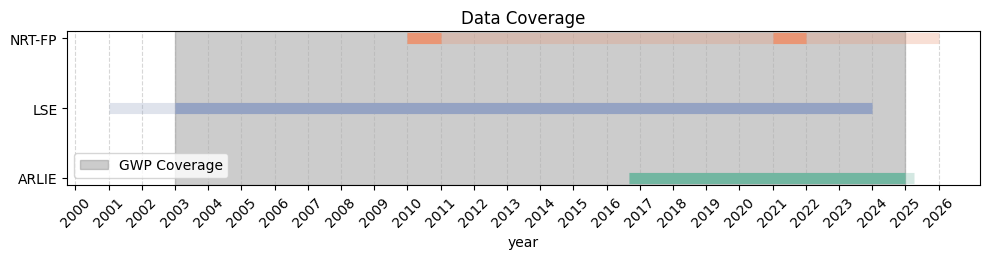

In [4]:

# Daten
data = [
    ("GWP",       "01.01.2003", "31.12.2024", None, None),
    ("ARLIE",     "01.09.2016", "01.04.2025", "01.09.2016", "31.12.2024"),
    ("LSE",        "01.01.2001", "31.12.2023", "01.01.2003", "31.12.2023"),
    ("NRT-FP", "01.01.2010", "31.12.2025", "01.01.2010", "31.12.2010"),  # volle Abdeckung + genutzte Jahre
]

# NRT-FP hat zwei Nutzzeiträume – erweitern:
# du kannst mehrere Einträge hinzufügen, um mehrere dunkle Segmente zu zeichnen
data.append(("NRT-FP", "01.01.2010", "31.12.2025", "01.01.2021", "31.12.2021"))


df = pd.DataFrame(data, columns=["Dataset", "Start1", "End1", "Start2", "End2"])

# Datumsparsing
for col in ["Start1", "End1", "Start2", "End2"]:
    df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

# Farben
colors = {
    "ARLIE": "#72B6A1",
    "LSE": "#95A3C3",
    "NRT-FP": "#E99675",
}


# Filtere die Datasets ohne GWP
datasets = [d for d in df["Dataset"].unique() if d != "GWP"]


# Plot
fig, ax = plt.subplots(figsize=(10, 2.7))

# === GWP als grauer Hintergrund ===
gwp_row = df[df["Dataset"] == "GWP"].iloc[0]
ax.axvspan(gwp_row["Start1"], gwp_row["End1"], color="grey", alpha=0.4, label="GWP Coverage")

# === Andere Datensätze ===
for i, dataset in enumerate(datasets):
    subset = df[df["Dataset"] == dataset]
    color = colors.get(dataset)

    # hell: gesamte Abdeckung
    full_start = subset["Start1"].min()
    full_end = subset["End1"].max()
    ax.plot(
        [full_start, full_end],
        [i, i],
        lw=8,
        alpha=0.3,
        color=color,
        solid_capstyle="butt"
    )

    # dunkel: tatsächliche Zeiträume
    for _, row in subset.iterrows():
        if pd.notna(row["Start2"]) and pd.notna(row["End2"]):
            ax.plot(
                [row["Start2"], row["End2"]],
                [i, i],
                lw=8,
                alpha=1.0,
                color=color,
                solid_capstyle="butt"
            )

# y-Ticks & Labels korrekt setzen
ax.set_yticks(range(len(datasets)))
ax.set_yticklabels(datasets)


# X-Achse: jedes Jahr
years = pd.date_range("2000-01-01", "2026-01-01", freq="YS")
ax.set_xticks(years)
ax.set_xticklabels([y.year for y in years], rotation=45)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Grid
ax.grid(axis="x", linestyle="--", alpha=0.5)

ax.set_xlabel("year")
ax.set_title("Data Coverage")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()


# Violin plots

In [3]:
import pandas as pd

In [4]:
stats_df_10 = pd.read_csv(r"T:\DLR\Analysis3\Results_10percDisr\all_stats_df.csv")


In [5]:
stats_df_10.head()

,Hylak_id,latitude,longitude,gwp_mean,val_mean,gwp_stdev,val_stdev,gwp_var,val_var,spearman_cor,R2,RMSE,MAE,Dataset,GLAKES_id,value-type
0,104,15.039006,58.532267,99.156366,97.684932,0.642204,2.620222,0.412425,6.865564,0.251576,0.063291,2.929547,1.614206,Arlie,NaN,Area-perc
1,141,42.947917,38.643750,99.405506,98.000000,0.272678,2.654859,0.074353,7.048276,0.344442,0.118640,2.948787,1.644484,Arlie,NaN,Area-perc
2,1054,16.519200,67.417005,46.476886,47.547945,47.371999,46.394275,2244.106262,2152.428720,0.883686,0.780902,5.933315,3.331843,Arlie,NaN,Area-perc
3,1094,11.631329,64.082765,89.699312,89.404110,22.139544,22.090591,490.159403,487.994190,0.553414,0.306267,6.175648,3.022107,Arlie,NaN,Area-perc
4,1105,23.622441,63.263175,64.536114,65.897260,43.974788,45.311600,1933.782019,2053.141096,0.806940,0.651152,9.656343,3.894360,Arlie,NaN,Area-perc


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

def order_by_median(df, group_col, value_col, ascending=True):
    """Return list of group labels ordered by median of value_col."""
    med = df.groupby(group_col)[value_col].median().sort_values(ascending=ascending)
    return med.index.tolist()


def save_metric_plots(stats_df, metrics, output_dir="plots", palette="Set2"):
    """
    Create and save one violin plot per metric and per value-type.

    Parameters
    ----------
    stats_df : pd.DataFrame
        DataFrame with columns ['Dataset', 'value-type', metric names].
    metrics : list of tuples
        Each tuple is (metric_name, title, higher_better).
    output_dir : str, optional
        Directory where plots will be saved. Created if it doesn't exist.
    palette : str or list, optional
        Seaborn color palette.
    """

    os.makedirs(output_dir, exist_ok=True)

    value_types = stats_df["value-type"].unique()

    for vt in value_types:
        df_vt = stats_df[stats_df["value-type"] == vt]

        for metric, title, higher_better in metrics:
            if metric not in df_vt.columns:
                print(f"⚠️ Skipping {metric} for {vt} (column missing)")
                continue

            ascending = not higher_better
            order = order_by_median(df_vt, 'Dataset_label', metric, ascending=ascending)

            fig, ax = plt.subplots(figsize=(8, 6))
            sns.violinplot(
                data=df_vt,
                x='Dataset_label',
                y=metric,
                hue='Dataset_label',
                order=order,
                ax=ax,
                palette=palette
            )

            ax.set_title(f"{title} – {vt}", fontweight='bold')
            ax.set_xlabel('')
            ax.tick_params(axis='x', rotation=45)

            plt.tight_layout()

            # Save to file
            filename = f"{metric}_{vt}.tif".replace(" ", "_")
            filepath = os.path.join(output_dir, filename)
            plt.savefig(filepath, dpi=300)
            plt.close(fig)

            print(f"✅ Saved: {filepath}")


# Example usage
metrics = [
    ('spearman_cor', 'Spearman ρ', True),
    ('RMSE', 'RMSE', False),
]

# save_metric_plots(stats_df_0, metrics, output_dir="plots_metrics")


In [7]:
stats_df_10['Dataset'].unique()

array(['Arlie', 'NASAFlood', 'Li', 'Li_no_frozen'], dtype=object)

In [8]:
# Define the mapping
name_map = {
    "Arlie": "ARLIE",
    "NASAFlood": "NRT NASA Flood Product",
    "Li": "global LSE (Li et al.) with freezing lakes",
    "Li_no_frozen": "global LSE (Li et al.)"
}


# Option 2: create a new column if you want to keep the original
stats_df_10["Dataset_label"] = stats_df_10["Dataset"].map(name_map)


In [9]:
stats_df_strict_li = stats_df_10[stats_df_10['Dataset']!='Li']


In [10]:
save_metric_plots(stats_df_strict_li, metrics, output_dir=r"T:\DLR\Analysis3\Plots_10percDisr")
save_metric_plots(stats_df_10, metrics, output_dir=r"T:\DLR\Analysis3\Plots_10percDisr\all_4")


✅ Saved: T:\DLR\Analysis3\Plots_10percDisr\spearman_cor_Area-perc.tif
✅ Saved: T:\DLR\Analysis3\Plots_10percDisr\RMSE_Area-perc.tif
✅ Saved: T:\DLR\Analysis3\Plots_10percDisr\spearman_cor_Area-normalized.tif
✅ Saved: T:\DLR\Analysis3\Plots_10percDisr\RMSE_Area-normalized.tif
✅ Saved: T:\DLR\Analysis3\Plots_10percDisr\all_4\spearman_cor_Area-perc.tif
✅ Saved: T:\DLR\Analysis3\Plots_10percDisr\all_4\RMSE_Area-perc.tif
✅ Saved: T:\DLR\Analysis3\Plots_10percDisr\all_4\spearman_cor_Area-normalized.tif
✅ Saved: T:\DLR\Analysis3\Plots_10percDisr\all_4\RMSE_Area-normalized.tif


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

def scatter_performance(stats_df, output_dir="plots_scatter", x_metric='spearman_cor', y_metric='RMSE'):
    """
    Create scatterplots (x=correlation, y=RMSE) for each value-type to compare datasets.

    Parameters
    ----------
    stats_df : pd.DataFrame
        DataFrame with columns ['Dataset', 'value-type', x_metric, y_metric].
    output_dir : str
        Directory where plots will be saved.
    x_metric : str
        Column name for x-axis (e.g. 'spearman_cor').
    y_metric : str
        Column name for y-axis (e.g. 'RMSE').
    """
    
    os.makedirs(output_dir, exist_ok=True)
    
    value_types = stats_df["value-type"].unique()

    for vt in value_types:
        df_vt = stats_df[stats_df["value-type"] == vt].copy()

        # Aggregate mean performance per dataset
        summary = (
            df_vt.groupby("Dataset_label", as_index=False)[[x_metric, y_metric]]
            .mean()
            .sort_values(by=x_metric, ascending=False)
        )

        palette = sns.color_palette("Set2", n_colors=df_vt["Dataset_label"].nunique())
        palette_dict = dict(zip(df_vt["Dataset_label"].unique(), palette))


        # --- Scatter plot ---
        plt.figure(figsize=(7, 6))
        ax = sns.scatterplot(
            data=df_vt,
            x=x_metric,
            y=y_metric,
            hue="Dataset_label",
            style="Dataset_label",
            palette = palette_dict,
            s=60,
            alpha=0.7
        )

        # Overlay dataset means
        sns.scatterplot(
            data=summary,
            x=x_metric,
            y=y_metric,
            hue="Dataset_label",
            palette = palette_dict,
            s=100,
            marker="s",
            edgecolor="black",
            linewidth=1.2,
            legend=False,
            ax=ax,
        )

        for _, row in summary.iterrows():
            ax.text(row[x_metric] + 0.01, row[y_metric], row["Dataset_label"],
                    fontsize=9, fontweight="bold", va="center")

        ax.set_title(f"Dataset performance – {vt}", fontweight="bold")
        ax.set_xlabel("Spearman correlation (ρ)")
        ax.set_ylabel("RMSE")
        ax.invert_yaxis()  # smaller RMSE = better
        ax.grid(True, linestyle='--', alpha=0.3)

        plt.tight_layout()
        os.makedirs(output_dir, exist_ok=True)
        filepath = os.path.join(output_dir, f"scatter_{vt}.tif")
        #plt.savefig(filepath, dpi=300)
        plt.show()
        plt.close()
        #print(f"✅ Saved scatter plot: {filepath}")


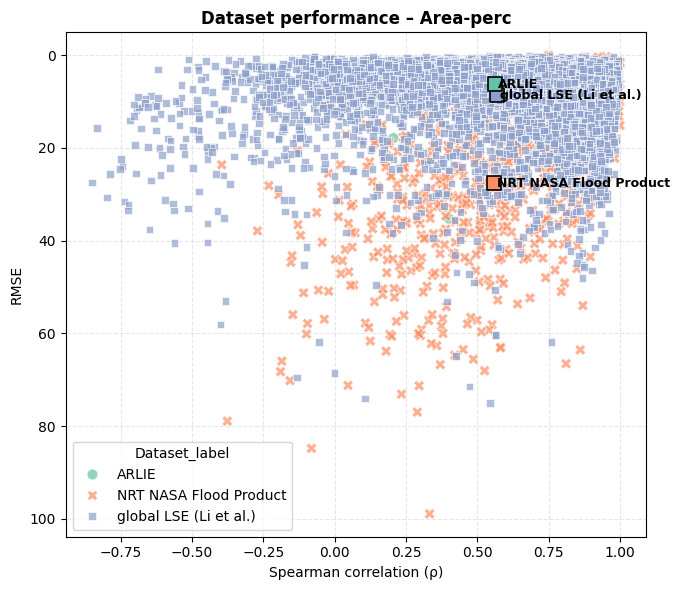

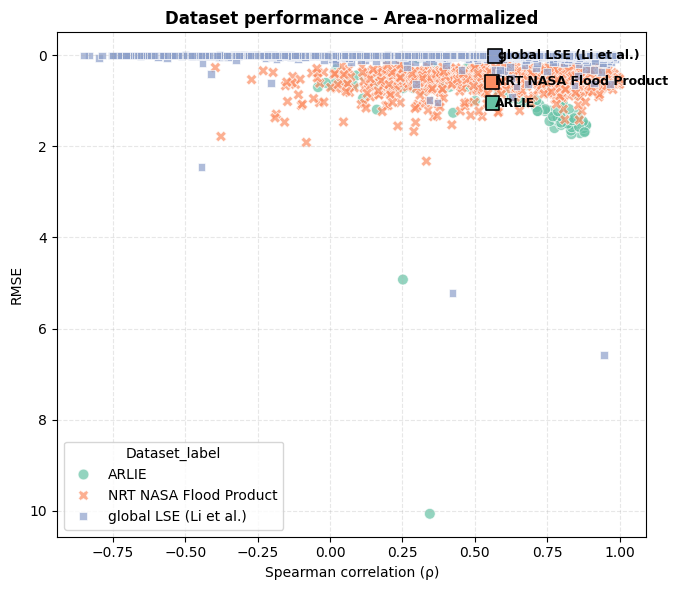

In [12]:
scatter_performance(stats_df_strict_li, output_dir=r"T:\DLR\Analysis3\Plots_10percDisr\overall_performance")

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

def scatter_performance(stats_df, output_dir="plots_scatter", 
                        x_metric='spearman_cor', y_metric='RMSE'):
    """
    Create scatterplots (x=correlation, y=RMSE) per value-type.
    For each value-type, create subplots (one per dataset) with shared axes.
    """

    os.makedirs(output_dir, exist_ok=True)
    value_types = stats_df["value-type"].unique()

    for vt in value_types:
        df_vt = stats_df[stats_df["value-type"] == vt].copy()

        # Get datasets and consistent color palette
        datasets = df_vt["Dataset_label"].unique()
        n_datasets = len(datasets)
        palette = sns.color_palette("Set2", n_colors=n_datasets)
        palette_dict = dict(zip(datasets, palette))

        # Add small jitter to reduce overlap
        df_vt[x_metric + "_j"] = df_vt[x_metric] + np.random.normal(0, 0.005, len(df_vt))
        df_vt[y_metric + "_j"] = df_vt[y_metric] + np.random.normal(0, 0.05, len(df_vt))

        # --- Create figure with subplots ---
        fig, axes = plt.subplots(1, n_datasets, figsize=(5 * n_datasets, 5), sharex=True, sharey=True)

        if n_datasets == 1:
            axes = [axes]  # ensure iterable if only one subplot

        for i, (dataset, ax) in enumerate(zip(datasets, axes)):
            df_sub = df_vt[df_vt["Dataset_label"] == dataset]

            # Scatterplot for individual lakes
            sns.scatterplot(
                data=df_sub,
                x=x_metric + "_j",
                y=y_metric + "_j",
                color=palette_dict[dataset],
                s=50,
                alpha=0.6,
                ax=ax
            )

            # Compute and overlay mean marker
            mean_x = df_sub[x_metric].mean()
            mean_y = df_sub[y_metric].mean()
            ax.scatter(mean_x, mean_y, color="black", s=80, marker="s", edgecolor="white", zorder=3)
            ax.text(mean_x + 0.01, mean_y, "mean", fontsize=9, fontweight="bold", va="center")

            # Style
            ax.set_title(dataset, fontweight="bold", fontsize=11)
            ax.grid(True, linestyle="--", alpha=0.3)
            ax.invert_yaxis()  # smaller RMSE = better
            if i == 0:
                ax.set_ylabel("RMSE")
            else:
                ax.set_ylabel("")
            ax.set_xlabel("Spearman correlation (ρ)")

        fig.suptitle(f"Dataset performance – {vt}", fontsize=13, fontweight="bold")
        plt.tight_layout(rect=[0, 0, 1, 0.95])

        # Save and show
        filepath = os.path.join(output_dir, f"scatter_subplots_{vt}.tif")
        plt.savefig(filepath, dpi=300)
        plt.show()
        plt.close(fig)

        print(f"✅ Created subplot comparison for {vt}")


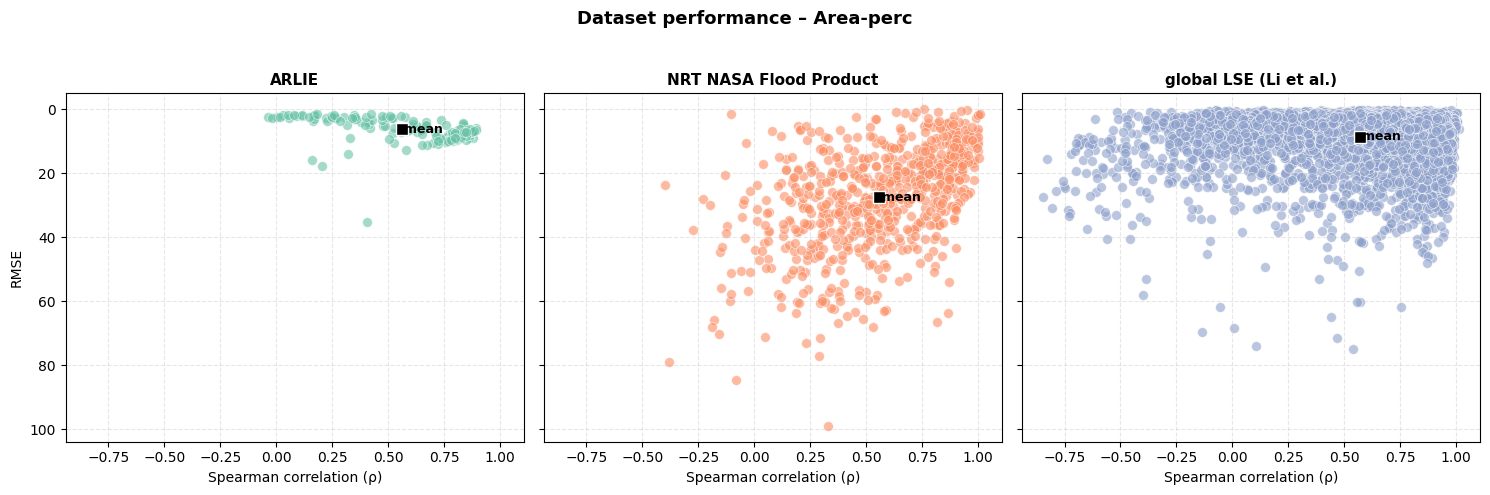

✅ Created subplot comparison for Area-perc


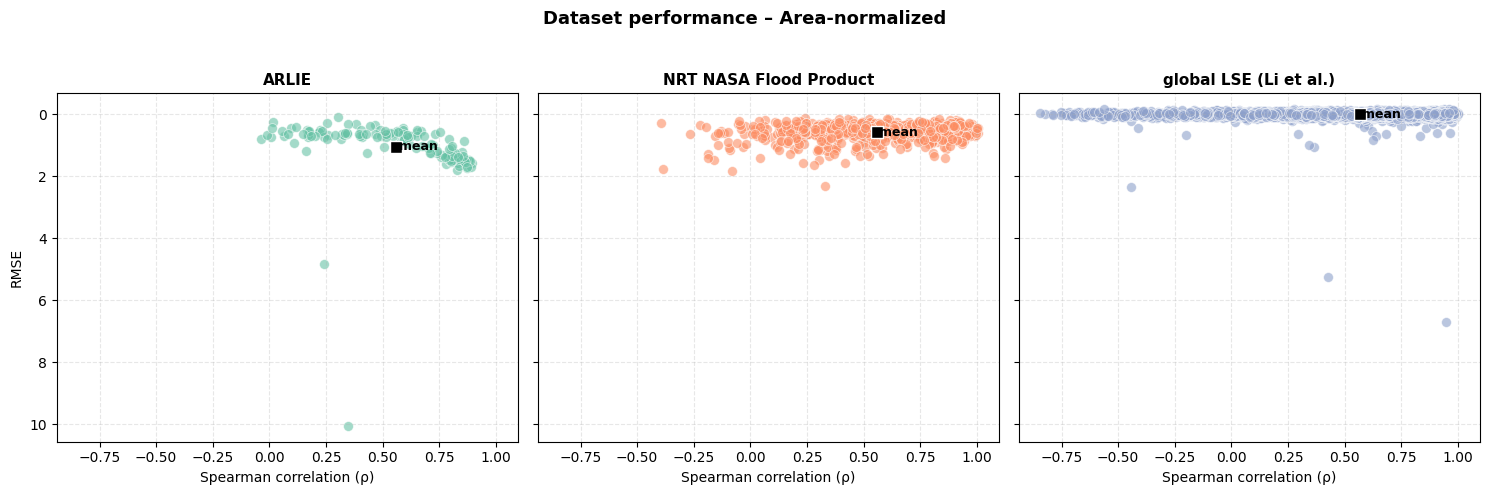

✅ Created subplot comparison for Area-normalized


In [14]:
scatter_performance(stats_df_strict_li, output_dir=r"T:\DLR\Analysis3\Plots_10percDisr\overall_performance")

# Summary dataframes


In [15]:

import pandas as pd

def summarize_metrics(stats_df):
    """
    Create summary DataFrames for RMSE and Spearman correlation.

    Parameters
    ----------
    stats_df : pd.DataFrame
        DataFrame with columns ['Dataset', 'value-type', 'RMSE', 'spearman_cor'].

    Returns
    -------
    rmse_summary : pd.DataFrame
        Summary stats (min, max, mean, median, std) for RMSE.
    spearman_summary : pd.DataFrame
        Same for Spearman correlation.
    """

    group_cols = ["Dataset", "value-type"]
    agg_funcs = ["min", "max", "mean", "median", "std"]

    rmse_summary = (
        stats_df.groupby(group_cols)["RMSE"]
        .agg(agg_funcs)
        .reset_index()
        .sort_values(group_cols)
    )

    spearman_summary = (
        stats_df.groupby(group_cols)["spearman_cor"]
        .agg(agg_funcs)
        .reset_index()
        .sort_values(group_cols)
    )

    return rmse_summary, spearman_summary


# Example usage:
# rmse_summary, spearman_summary = summarize_metrics(stats_df_0)
# print("\nRMSE Summary:\n", rmse_summary)
# print("\nSpearman Summary:\n", spearman_summary)


In [17]:
rmse_summary, spearman_summary = summarize_metrics(stats_df_strict_li)

In [18]:
print("\nRMSE Summary:\n", rmse_summary)
print("\nSpearman Summary:\n", spearman_summary)


RMSE Summary:
         Dataset       value-type       min        max       mean     median  \
0         Arlie  Area-normalized  0.068514  10.064573   1.050538   0.775640   
1         Arlie        Area-perc  1.562895  35.310459   6.317619   6.182527   
2  Li_no_frozen  Area-normalized  0.000454   6.582523   0.011399   0.003062   
3  Li_no_frozen        Area-perc  0.139585  75.034582   8.687322   6.266987   
4     NASAFlood  Area-normalized  0.174689   2.324821   0.583271   0.526667   
5     NASAFlood        Area-perc  0.042294  98.878812  27.578715  25.460976   

         std  
0   0.933129  
1   4.025639  
2   0.118016  
3   7.731603  
4   0.261677  
5  15.855540  

Spearman Summary:
         Dataset       value-type       min       max      mean    median  \
0         Arlie  Area-normalized -0.041586  0.884329  0.560880  0.618269   
1         Arlie        Area-perc -0.041586  0.884329  0.560879  0.618269   
2  Li_no_frozen  Area-normalized -0.850602  0.997660  0.568869  0.650121   
3

# Timeseries plots

In [41]:
import gc
gc.collect()

8762839

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

In [43]:
ts_folder = Path(r"T:\DLR\Analysis3\Output\Li\02_dataForTimeSeriesPlots")
ts_dict = {}
for file in ts_folder.glob("*.csv"):
    df = pd.read_csv(file)
    name = df["Filename"].iloc[0]
    #title = file.stem
    ts_dict[name] = df

In [44]:
ts_dict.keys()

dict_keys(['h19v02_Lovozero_1_SGV-timeseries_allDates_rm2902.txt', 'h13v02_Itchen_1_SGV-timeseries_allDates_rm2902.txt', 'h27v06_1501_2_SGV-timeseries_allDates_rm2902.txt', 'h21v08_Baringo_1_SGV-timeseries_allDates_rm2902.txt', 'h22v03_MalyyeChany_1_SGV-timeseries_allDates_rm2902.txt', 'h27v06_1505_2_SGV-timeseries_allDates_rm2902.txt', 'h12v10_925_1_SGV-timeseries_allDates_rm2902.txt', 'h11v10_LagoCoipasa_1_SGV-timeseries_allDates_rm2902.txt', 'h20v09_Zimbambo_1_SGV-timeseries_allDates_rm2902.txt', 'h12v03_455_1_SGV-timeseries_allDates_rm2902.txt', "h25v05_Jen-ch'inghsiu-pu-ts'o_1_SGV-timeseries_allDates_rm2902.txt", 'h27v06_15397_1_SGV-timeseries_allDates_rm2902.txt', 'h11v03_Canoe_1_SGV-timeseries_allDates_rm2902.txt', 'h13v14_Toro_1_SGV-timeseries_allDates_rm2902.txt', 'h21v03_BolshoyUvat_1_SGV-timeseries_allDates_rm2902.txt', 'h23v04_Jili_1_SGV-timeseries_allDates_rm2902.txt', 'h13v11_PortoPrimaveraReservoir_2_SGV-timeseries_allDates_rm2902.txt', 'h13v04_755_1_SGV-timeseries_allDa

In [45]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def quick_monthly_plot(*datasets_and_titles, figwidth=14, subplot_height=3.5):
    colors = ["#1B9E77", "#D95F02", "#7570B3"] 
    plt.rcParams['figure.dpi'] = 300
    
    n_plots = len(datasets_and_titles)
    if n_plots == 0:
        print("Keine Datasets übergeben!")
        return
    
    fig_height = subplot_height * n_plots
    fig, ax = plt.subplots(nrows=n_plots, figsize=(figwidth, fig_height))
    if n_plots == 1:
        ax = [ax]
    
    for i, (df, title) in enumerate(datasets_and_titles):
        if "Date" in df.columns:
            df = df.copy()
            df["Date"] = pd.to_datetime(df["Date"])
            df = df.set_index("Date")
        df = df.sort_index()
        
        # GWP Plot
        if "GWP_lake_surface_area" in df.columns:
            ax[i].plot(df.index, df["GWP_lake_surface_area"], 
                       label='GWP', color=colors[0], linewidth=2)
        
        # Li Plot
        if "li_lake_surface_area_km2" in df.columns:
            ax[i].plot(df.index, df["li_lake_surface_area_km2"], 
                       label='Li et al', color=colors[1], linewidth=2)

        # ---- Frozen Tag einbauen ----
        if "frozen" in df.columns:
            frozen_periods = df[df["frozen"] == True]
            if not frozen_periods.empty:
                ax[i].scatter(frozen_periods.index, frozen_periods["li_lake_surface_area_km2"],
                              color="blue", s=20, label="Frozen", zorder=5, alpha=0.7)
                for t in frozen_periods.index:
                    ax[i].axvspan(t - pd.Timedelta(days=15), 
                                  t + pd.Timedelta(days=15),
                                  color="lightblue", alpha=0.2)

        # Styling
        ax[i].set_title(title, fontsize=12, fontweight='bold')
        ax[i].legend()
        ax[i].grid(True, alpha=0.3)
        ax[i].set_ylabel('Surface Area (km²)')
        ax[i].spines[["top", "right"]].set_visible(False)
        ax[i].xaxis.set_major_locator(mdates.YearLocator(2))
        ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax[i].tick_params(axis='x', rotation=45)
        if i == n_plots - 1:
            ax[i].set_xlabel('Year')
    
    plt.tight_layout()
    return fig   


C:\Users\elena\AppData\Local\Temp\ipykernel_21324\2837852558.py:3: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(rf"t:\DLR\Analysis3\Plots_10percDisr\timeseries\{name}.tif", dpi=300)


MemoryError: bad allocation

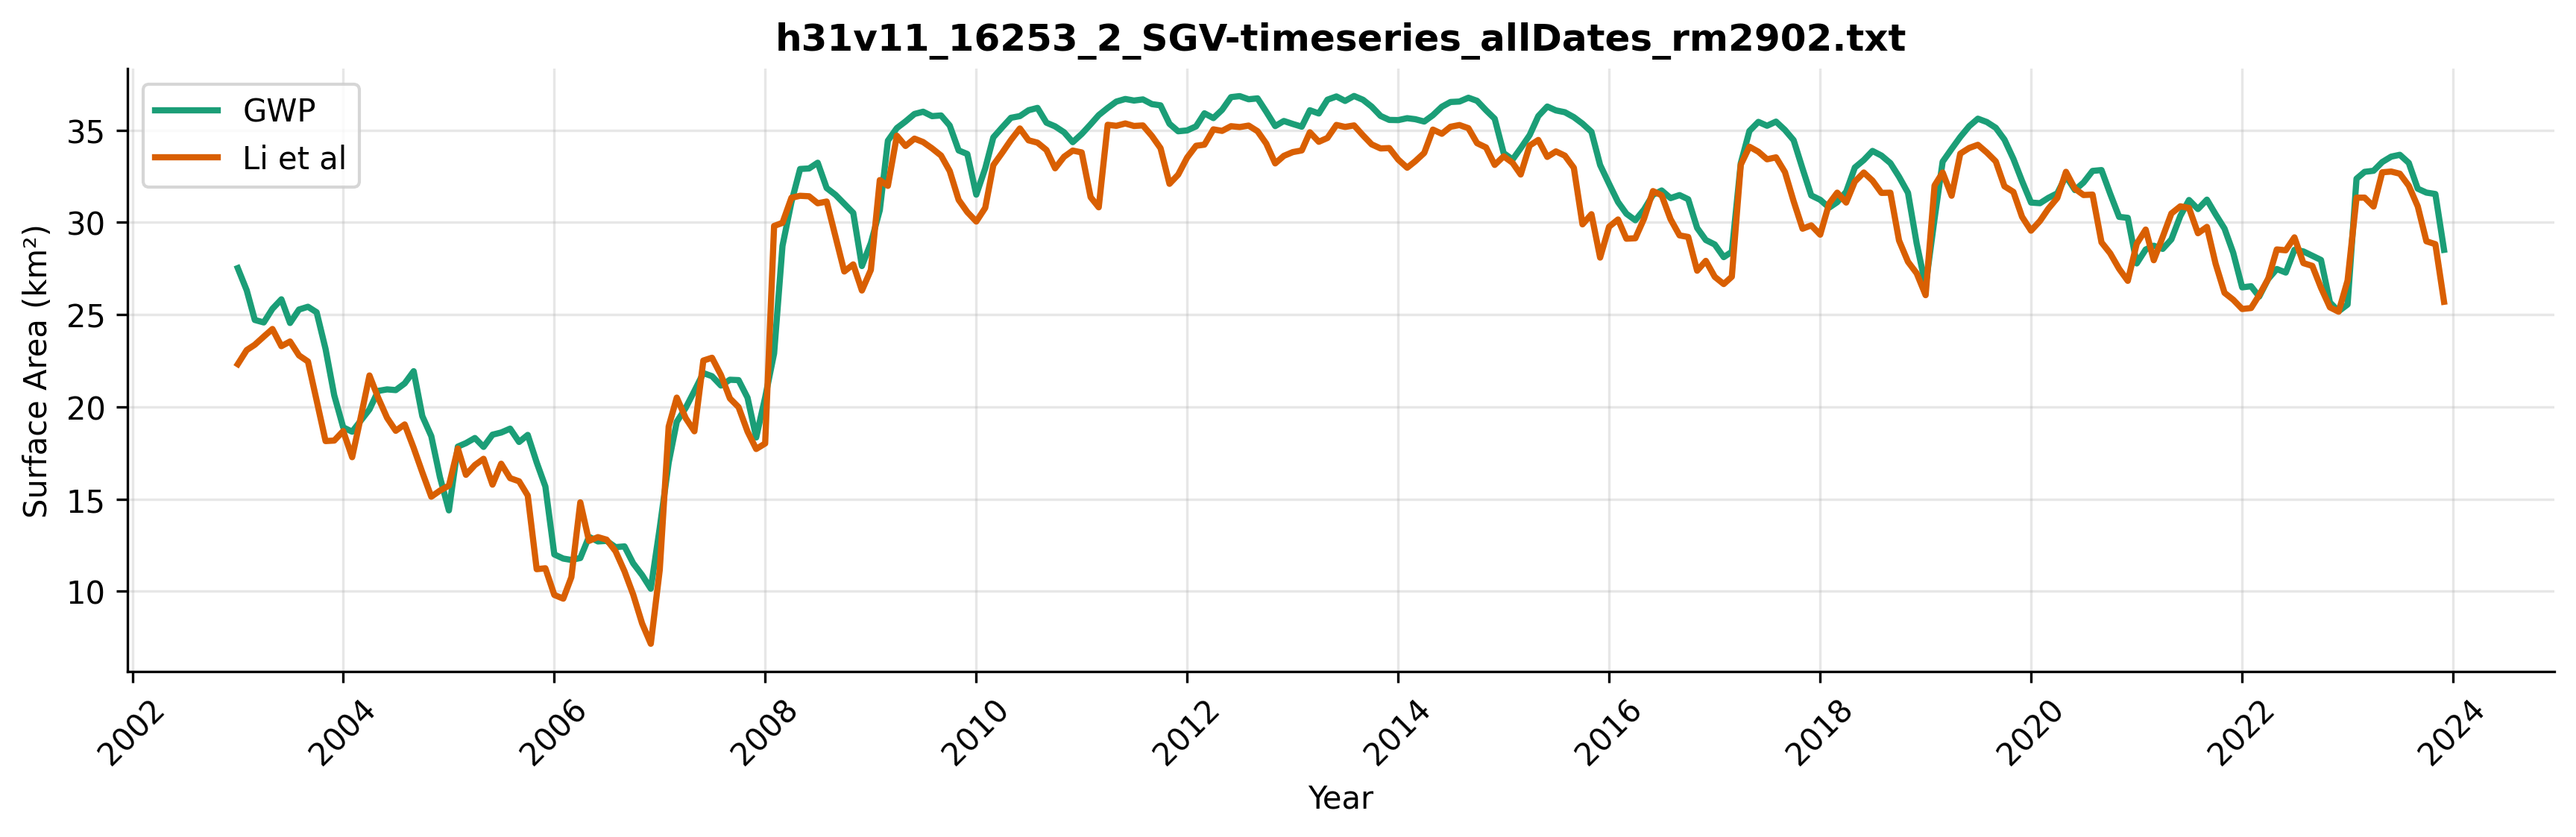

In [46]:
for name, df in ts_dict.items():
    fig = quick_monthly_plot((df, name))
    fig.savefig(rf"t:\DLR\Analysis3\Plots_10percDisr\timeseries\{name}.tif", dpi=300)
    plt.close(fig)
